In [174]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [175]:
df = pd.read_csv("car_fuel_efficiency_2026.csv.1")

In [176]:
df = df[["engine_displacement","horsepower","vehicle_weight","model_year","fuel_efficiency_mpg"]]

In [177]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


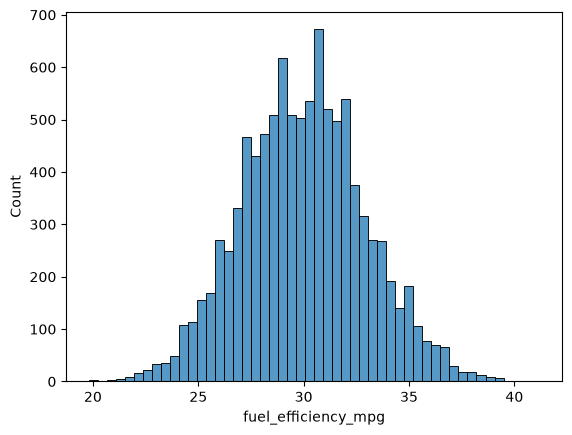

In [178]:
sns.histplot(df["fuel_efficiency_mpg"],bins = 50)
plt.show()

In [179]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [180]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


In [181]:
# Shuffling the filtered data and splitting it as in the dataset
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train+n_val:]]


In [220]:
X_train= df_train.iloc[:, :4]
X_train

X_val = df_val.iloc[:,:4]

In [221]:
y_train = np.array(df_train.iloc[:,-1])
y_train

y_val = np.array(df_val.iloc[:,-1])


In [222]:
def linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y) 

    return w_full[0], w_full[1:]


In [223]:
df_train.isnull().sum()

engine_displacement      0
horsepower             545
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [224]:
# Filling with the missing values as 0
X_train_fill0 = X_train.fillna(0).values
w0, w = linear_regression(X_train_fill0, y_train)
X_val_fill0 = X_val.fillna(0).values

y_pred_fill0 = w0 + X_val_fill0.dot(w)

<Axes: ylabel='Count'>

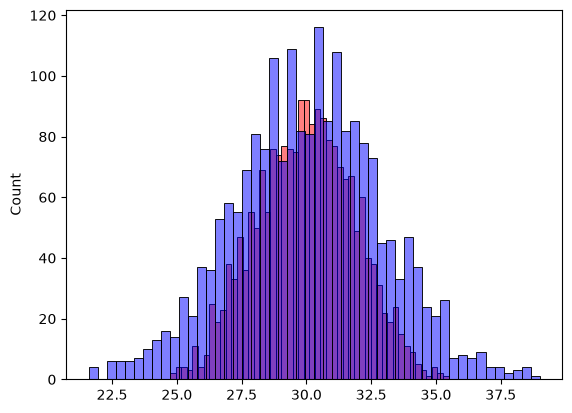

In [225]:
sns.histplot(y_pred_fill0, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

In [226]:
mean = np.mean(X_train["horsepower"])
X_train_fillmean = X_train.fillna(mean)
X_val_fillmean = X_val.fillna(mean)
w0_new, w_new = linear_regression(X_val_fillmean, y_val)
y_pred_fillmean = w0_new + X_val_fillmean.dot(w_new)

<Axes: ylabel='Count'>

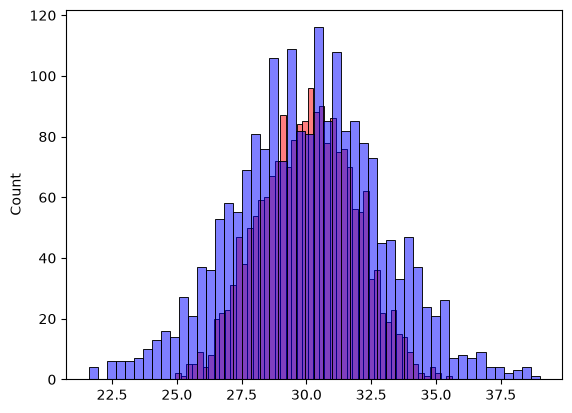

In [227]:
sns.histplot(y_pred_fillmean, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)

In [228]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error **2
    mse = se.mean()
    rmse = np.sqrt(mse)
    return rmse
   

In [229]:
print("RMSE with filling them as 0: ",rmse(y_val,y_pred_fill0))
print("RMSE with filling them as mean: ",rmse(y_val,y_pred_fillmean))


RMSE with filling them as 0:  2.2070365928200184
RMSE with filling them as mean:  2.2008041867735697


In [230]:
def linear_regression_reg(X,y,r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])

    XTX = X.T.dot(X)
    XTX = XTX + r*np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y) 

    return w_full[0], w_full[1:]

In [231]:
X_train_fill0 = X_train.fillna(0).values
w0_reg_1, w_reg_1 = linear_regression_reg(X_train_fill0, y_train, 0)
X_val_fill0 = X_val.fillna(0).values

y_pred_fill0_reg_0 = w0_reg_1 + X_val_fill0.dot(w_reg_1)
print("RMSE with r as 0: ",rmse(y_val,y_pred_fill0_reg_0))

RMSE with r as 0:  2.2070365928200184


In [232]:
# [0, 0.01, 0.1, 1, 5, 10, 100]
X_train_fill0 = X_train.fillna(0).values
w0_reg_2, w_reg_2 = linear_regression_reg(X_train_fill0, y_train, 0.01)
X_val_fill0 = X_val.fillna(0).values

y_pred_fill0_reg_1 = w0_reg_2 + X_val_fill0.dot(w_reg_2)
print("RMSE with r as 0.01: ",rmse(y_val,y_pred_fill0_reg_1))

RMSE with r as 0.01:  2.2066564366620898


In [233]:
X_train_fill0 = X_train.fillna(0).values
w0_reg_2, w_reg_2 = linear_regression_reg(X_train_fill0, y_train, 0.1)
X_val_fill0 = X_val.fillna(0).values

y_pred_fill0_reg_1 = w0_reg_2 + X_val_fill0.dot(w_reg_2)
print("RMSE with r as 0.1: ",rmse(y_val,y_pred_fill0_reg_1))

RMSE with r as 0.1:  2.2195263572767


In [234]:
X_train_fill0 = X_train.fillna(0).values
w0_reg_2, w_reg_2 = linear_regression_reg(X_train_fill0, y_train, 1)
X_val_fill0 = X_val.fillna(0).values

y_pred_fill0_reg_1 = w0_reg_2 + X_val_fill0.dot(w_reg_2)
print("RMSE with r as 1: ",rmse(y_val,y_pred_fill0_reg_1))

RMSE with r as 1:  2.3364483047472038


In [235]:
X_train_fill0 = X_train.fillna(0).values
w0_reg_2, w_reg_2 = linear_regression_reg(X_train_fill0, y_train, 5)
X_val_fill0 = X_val.fillna(0).values

y_pred_fill0_reg_1 = w0_reg_2 + X_val_fill0.dot(w_reg_2)
print("RMSE with r as 5: ",rmse(y_val,y_pred_fill0_reg_1))

RMSE with r as 5:  2.3951516387371785


In [236]:
X_train_fill0 = X_train.fillna(0).values
w0_reg_2, w_reg_2 = linear_regression_reg(X_train_fill0, y_train, 10)
X_val_fill0 = X_val.fillna(0).values

y_pred_fill0_reg_1 = w0_reg_2 + X_val_fill0.dot(w_reg_2)
print("RMSE with r as 10: ",rmse(y_val,y_pred_fill0_reg_1))

RMSE with r as 10:  2.4050615243783335


In [237]:
X_train_fill0 = X_train.fillna(0).values
w0_reg_2, w_reg_2 = linear_regression_reg(X_train_fill0, y_train, 100)
X_val_fill0 = X_val.fillna(0).values

y_pred_fill0_reg_1 = w0_reg_2 + X_val_fill0.dot(w_reg_2)
print("RMSE with r as 100: ",rmse(y_val,y_pred_fill0_reg_1))

RMSE with r as 100:  2.4146342231998457


In [238]:
# Shuffling the filtered data and splitting it
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

rmse_scores = []

for seed in range(10):

    np.random.seed(seed)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    # Use all 4 features
    X_train = df_train.iloc[:, :4].fillna(0).values
    y_train = df_train.iloc[:, -1].values

    X_val = df_val.iloc[:, :4].fillna(0).values
    y_val = df_val.iloc[:, -1].values

    # Train without regularization
    w0, w = linear_regression(X_train, y_train)

    # Predict validation data
    y_pred = w0 + X_val.dot(w)

    # RMSE
    score = rmse(y_val, y_pred)
    rmse_scores.append(score)

    print(f"Seed {seed}: RMSE = {score:.3f}")

# Standard deviation of all 10 RMSE scores
std = np.std(rmse_scores)

print("Standard deviation:", round(std, 3))

Seed 0: RMSE = 2.239
Seed 1: RMSE = 2.202
Seed 2: RMSE = 2.163
Seed 3: RMSE = 2.204
Seed 4: RMSE = 2.202
Seed 5: RMSE = 2.246
Seed 6: RMSE = 2.270
Seed 7: RMSE = 2.191
Seed 8: RMSE = 2.217
Seed 9: RMSE = 2.207
Standard deviation: 0.029


In [239]:
# Split using seed 9
np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# Combine train + validation
df_train_full = pd.concat([df_train, df_val])

# Separate features and target
X_train_full = df_train_full.iloc[:, :-1].fillna(0).values
y_train_full = df_train_full.iloc[:, -1].values

X_test = df_test.iloc[:, :-1].fillna(0).values
y_test = df_test.iloc[:, -1].values

# Train regularized linear regression
w0, w = linear_regression_reg(X_train_full, y_train_full, 0.001)

# Predict on TEST data
y_pred = w0 + X_test.dot(w)

# Calculate TEST RMSE
score = rmse(y_test, y_pred)

print("RMSE:", score)
print("Rounded:", round(score, 3))

RMSE: 2.2358277471938868
Rounded: 2.236
